# Cluster-size sensitivity: 2x2 vs 3x3 SAFT-P plaquettes

Referee point R2C1 asks how much the predicted phase boundary depends on the size of the
square cluster.  This notebook repeats the stick and L-shaped calculations with a **3x3**
plaquette and compares with the published **2x2** results.

The construction is the same one used in `spinodal_stick_shaped.ipynb` /
`spinodal_l_shaped.ipynb`:

* microstates are grouped by their outgoing boundary-edge pattern, modulo a global $C_4$
  rotation, **and by their composition** (`composition_key="components"`, section 2b) —
  rotating a cluster is a symmetry and may be collapsed, changing what it is made of is not;
* microstates inside a class are Boltzmann-averaged;
* the reduced solve carries the composition multiplier $\mu$ and the free super-patch
  abundances $W_s$, with the class populations $\rho_p$ eliminated by a softmax.

What changes when the plaquette grows:

| | $2\times2$ | $3\times3$ |
|---|---|---|
| sites | 4 | 9 |
| internal bonds | 4 | 12 |
| boundary slots per side | 2 | 3 |
| super-edge types (binary patch + vacancy patch) | $3^2 = 9$ | $3^3 = 27$ |
| super-edges per plaquette | 4 | 4 |
| **interior (boundary-invisible) sites** | **0** | **1** |
| raw microstates, stick / L | 81 / 625 | 19,683 / 1,953,125 |
| boundary classes, stick / L | 24 / 165 | 1,665 / 12,720 |

Note the Newton dimension is $1 + F$ where $F$ is the number of super-edge *types*, so it
goes from 10 to 28 — it does **not** scale with the number of classes.  That is why 3x3 is
tractable at all: the class count only enters through one $P\times F$ matrix product.

Cost on a laptop, per free-energy curve of 151 $\phi$ points: about 5 s (stick 3x3) and
about 25 s (L 3x3), versus milliseconds at 2x2.

## Three knobs that are inert at 2x2 and are not at 3x3

**`composition_key`** — the boundary signature does not determine what a plaquette is made
of, so with the plain key a class can mix microstates with different particle counts and
$A_p$ becomes a fractional Boltzmann average.  `composition_key="components"` (the default)
adds the count per chemical component to the class key, which makes $A_p$ exact, makes
$\phi$ span $[0,1]$ for any `interior_key`, and removes the residual dependence of the class
internal free energy on the build-time $\mu$.  At $2\times2$ it changes nothing for these two
geometries (verified in section 2b); it is the general statement of which `interior_key`
below is the $3\times3$-specific special case.

**`interior_key`** — a weaker, geometry-specific version of the same idea: it pins the
occupancy *pattern* of the hidden sites rather than the total composition.  At $2\times2$ every
site touches the boundary, so the boundary signature
fixes the plaquette composition exactly and $\phi$ spans $[0,1]$.  At $3\times3$ the centre
site is invisible to the boundary.  If it is simply Boltzmann-averaged
(`interior_key="none"`, the literal generalisation of the published recipe) its occupancy is
frozen at the ideal value $(S-1)/S$, so the theory **cannot reach $\phi < 2/27$ (stick) or
$\phi < 4/45$ (L)** and has no pure-solvent phase.  Labelling classes additionally by the
interior *occupancy* (`interior_key="occupancy"`, the default here) restores $\phi\in[0,1]$ at
the cost of exactly doubling the class count.  The interior *orientation* is still
Boltzmann-averaged, which is harmless because orientation carries no composition.

**`internal_term`** — the published code puts the Boltzmann-averaged internal *energy*
$\langle E\rangle_p$ in the class exponent and sets the multiplicity to 1, so the internal
entropy of a class is discarded.  At $2\times2$ a class holds a handful of microstates; at
$3\times3$ it holds hundreds, so the discarded entropy grows with cluster size and would
contaminate the comparison.  `internal_term="class_free_energy"` uses $g_p = -\log Z_p$
instead, keeping the full internal partition function.  Section 3 shows this is the difference
between an exact and a badly wrong non-interacting limit.

**For a controlled 2x2-vs-3x3 comparison, hold `internal_term` fixed at
`class_free_energy`, `composition_key` at `"components"`, and use
`interior_key="occupancy"`.**  The `mean_energy` rows are kept so
the $2\times2$ numbers can be tied back to the published figures.

In [1]:
%matplotlib inline
# --- repo path setup (matches the other notebooks) ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

import json, time
import numpy as np
import matplotlib.pyplot as plt

from plaquette_nxn_by_species import build_plaquettes_nxn_by_species, count_classes
from saftp_reduced_nxn import (build_S_matrix, solve_free_energy_curve, loess_derivs,
                               zero_crossings_linear, excess_above_tangent)
from saftp_scan_nxn import (GEOMETRIES, make_J, build_reduced_inputs, free_energy_curve,
                            analyse_curve, has_two_phase, bisect_critical_eps_a,
                            map_two_phase_region, two_phase_mask)

PHIS = np.linspace(0.01, 0.99, 151)          # same grid as the published scans
DATA = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))

# Class key for every scan below.  "components" (the builder default) keys a
# class on (boundary signature, count per chemical component) instead of the
# boundary signature alone -- see section 2b.  "none" reproduces the published
# class definition.  At the settings used in sections 5 and 6 the two give
# identical class lists for these two geometries, so the cached JSON results
# stay valid either way; section 2b shows where the distinction does bite.
COMPOSITION_KEY = 'components'

for k, g in GEOMETRIES.items():
    print(k, 'species =', len(g['patches']), ' patches =', g['patches'].tolist())

stick species = 3  patches = [[1, 0, 1, 0], [0, 1, 0, 1], [2, 2, 2, 2]]
L species = 5  patches = [[1, 1, 0, 0], [0, 1, 1, 0], [0, 0, 1, 1], [1, 0, 0, 1], [2, 2, 2, 2]]


## 1. How big does the problem actually get?

`count_classes` is purely combinatorial (no energies): raw microstate count, distinct ordered
boundary 4-tuples, and how many survive the $C_4$ quotient.

In [2]:
rows = []
for name, g in GEOMETRIES.items():
    for n in (2, 3):
        micro, raw, canon = count_classes(g['patches'], g['rot90_species'], n=n)
        c = {}
        for ik in ('none', 'occupancy', 'species'):
            for ck in ('none', 'components'):
                inp = build_reduced_inputs(g['patches'], g['rot90_species'], 4.0, 1.5,
                                           n=n, interior_key=ik, composition_key=ck)
                c[(ik, ck)] = (inp[6]['P'], inp[6]['F'], inp[0].min(), inp[0].max(),
                               inp[6]['A_row_max_noninteger'])
        rows.append((name, n, micro, canon, c))

hdr = (f"{'geom':6s} {'n':>2s} {'microstates':>12s} {'boundary cls':>13s} "
       f"{'+int.occ':>10s} {'+int.species':>13s} {'F':>4s} {'phi range (occ)':>19s}")
print(hdr); print('-' * len(hdr))
for name, n, micro, canon, c in rows:
    print(f"{name:6s} {n:2d} {micro:12,d} {canon:13,d} {c[('occupancy','none')][0]:10,d} "
          f"{c[('species','none')][0]:13,d} {c[('none','none')][1]:4d} "
          f"[{c[('occupancy','none')][2]:.4f}, {c[('occupancy','none')][3]:.4f}]")

print("\nreachable phi with interior_key='none' (the naive 3x3 generalisation):")
for name, n, micro, canon, c in rows:
    print(f"   {name:6s} n={n}: [{c[('none','none')][2]:.4f}, {c[('none','none')][3]:.4f}]")

# ---------------------------------------------------------------------------
# What the composition key does to the same table.
#
# interior_key pins the occupancy *pattern* of the hidden sites; composition_key
# pins the *total* composition of the whole plaquette.  With composition_key on,
# the class composition is exact and phi spans [0, 1] for ANY interior_key, so
# the interior_key='none' shortfall above disappears without an n-specific fix.
print(f"\n{'geom':6s} {'n':>2s} {'interior_key':13s} {'comp_key':12s} "
      f"{'P':>7s} {'phi range':>18s} {'max|nA-round|':>14s}")
for name, n, micro, canon, c in rows:
    for ik in ('none', 'occupancy'):
        for ck in ('none', 'components'):
            P_, F_, lo, hi, nonint = c[(ik, ck)]
            print(f"{name:6s} {n:2d} {ik:13s} {ck:12s} {P_:7,d} "
                  f"[{lo:.4f}, {hi:.4f}] {nonint:14.2e}")

geom    n  microstates  boundary cls   +int.occ  +int.species    F     phi range (occ)
--------------------------------------------------------------------------------------
stick   2           81            24         24            24    9 [0.0000, 1.0000]
stick   3       19,683         1,665      3,330         4,986   27 [0.0000, 1.0000]
L       2          625           165        165           165    9 [0.0000, 1.0000]
L       3    1,953,125        12,720     25,440        63,345   27 [0.0000, 1.0000]

reachable phi with interior_key='none' (the naive 3x3 generalisation):
   stick  n=2: [0.0000, 1.0000]
   stick  n=3: [0.0741, 1.0000]
   L      n=2: [0.0000, 1.0000]
   L      n=3: [0.0889, 1.0000]


## 2. Regression: at n = 2 the new code *is* the old code

`build_plaquettes_nxn_by_species(..., n=2)` must reproduce
`build_plaquettes_by_species(..., use_4_patch=True, canonicalize_by_boundary_edges=True)`
element for element, and the generalised solver must reproduce
`solve_free_energy_curve_reduced_square`.  Run this before trusting anything below.

In [3]:
from plaquette_by_species import build_plaquettes_by_species

def _S(p2s, p2sm, mp, P, F):
    S = np.zeros((P, F))
    for k in range(len(p2s)):
        S[p2s[k], p2sm[k]] += mp[k]
    return S

print(f"{'geom':6s} {'eps_a':>6s} {'eps_c':>6s} {'P':>5s}  "
      f"{'d(eps_small)':>12s} {'d(intra)':>10s} {'d(species)':>11s} {'d(S)':>10s}")
for name, g in GEOMETRIES.items():
    for ea, ec in [(4.0, 1.5), (7.3, 0.31), (0.0, 0.0), (2.0, 0.2)]:
        P_, R_ = g['patches'], g['rot90_species']
        J = make_J(P_, ea, ec)
        # Both sides pinned to composition_key="none": this cell is the
        # regression against the *published* class definition, so it must not
        # silently pick up the new composition-aware default.  The
        # composition_key="components" comparison is section 2b below.
        old = build_plaquettes_by_species(P_, J, np.zeros(len(P_)), rot90_species=R_,
                                          canonicalize_by_boundary_edges=True,
                                          canonicalize_by_edges=False, use_4_patch=True,
                                          composition_key="none")
        new = build_plaquettes_nxn_by_species(P_, J, np.zeros(len(P_)), rot90_species=R_, n=2,
                                              composition_key="none")
        P, F = len(old[1]), old[0].shape[0]
        So, Sn = _S(old[4], old[5], old[3], P, F), _S(new[4], new[5], new[3], P, F)
        # classes come out in a different order; sort both by their (S, e, composition) row
        ko = np.lexsort(np.round(np.column_stack([So, old[1], old[2]]), 9).T)
        kn = np.lexsort(np.round(np.column_stack([Sn, new[1], new[2]]), 9).T)
        print(f"{name:6s} {ea:6.2f} {ec:6.2f} {P:5d}  "
              f"{np.abs(old[0]-new[0]).max():12.2e} {np.abs(old[1][ko]-new[1][kn]).max():10.2e} "
              f"{np.abs(old[2][ko]-new[2][kn]).max():11.2e} {np.abs(So[ko]-Sn[kn]).max():10.2e}")

geom    eps_a  eps_c     P  d(eps_small)   d(intra)  d(species)       d(S)
stick    4.00   1.50    24      0.00e+00   0.00e+00    0.00e+00   0.00e+00
stick    7.30   0.31    24      0.00e+00   0.00e+00    0.00e+00   0.00e+00
stick    0.00   0.00    24      0.00e+00   0.00e+00    0.00e+00   0.00e+00
stick    2.00   0.20    24      0.00e+00   0.00e+00    4.44e-16   0.00e+00
L        4.00   1.50   165      0.00e+00   0.00e+00    0.00e+00   0.00e+00
L        7.30   0.31   165      0.00e+00   0.00e+00    0.00e+00   0.00e+00
L        0.00   0.00   165      0.00e+00   0.00e+00    0.00e+00   0.00e+00
L        2.00   0.20   165      0.00e+00   0.00e+00    3.33e-16   0.00e+00


In [4]:
# Same check one level up: the free-energy curve itself.
# orig_solver_ref.py is cell 1 of spinodal_stick_shaped.ipynb saved verbatim as a
# module (its __main__ block does not run on import), so the published solver can
# be called side by side.  Skip this cell if you would rather not keep that copy --
# the builder regression above is the load-bearing one.
import orig_solver_ref as REF

for name, g in GEOMETRIES.items():
    for ea, ec in [(4.0, 1.5), (6.0, 0.6), (2.0, 0.2)]:
        P_, R_ = g['patches'], g['rot90_species']
        J = make_J(P_, ea, ec)
        o = build_plaquettes_by_species(P_, J, np.zeros(len(P_)), rot90_species=R_,
                                        canonicalize_by_boundary_edges=True, use_4_patch=True,
                                        composition_key="none")
        eps_s, intra, p2sp, mp, p2s, p2sm, cfg, mult = o
        A = np.sum(p2sp[:, :-1], axis=1) / 4.0
        P, F = len(A), int(p2sm.max()) + 1
        S = build_S_matrix(p2s, p2sm, mp, P, F)
        c_old = REF.solve_free_energy_curve_reduced_square(
            PHIS, A, intra, np.log(mult + 1e-300), S, (np.exp(-eps_s) - 1.0) / 4.0,
            mu_init=0.0, W_init=None, max_newton=180, tol=1e-8, accept_residual=1e-6)
        inp = build_reduced_inputs(P_, R_, ea, ec, n=2, composition_key="none")
        c_new = solve_free_energy_curve(PHIS, *inp[:6], max_newton=180, tol=1e-8,
                                        accept_residual=1e-6, logW=False)
        m = ~np.isnan(c_old['f']) & ~np.isnan(c_new['f'])
        print(f"{name:6s} eps_a={ea:4.1f} eps_c={ec:4.2f}  "
              f"n_valid old/new = {np.sum(~np.isnan(c_old['f'])):3d}/{np.sum(~np.isnan(c_new['f'])):3d}"
              f"  max|df| = {np.abs(c_old['f'][m]-c_new['f'][m]).max():.2e}")

stick  eps_a= 4.0 eps_c=1.50  n_valid old/new =  68/151  max|df| = 1.81e-09


stick  eps_a= 6.0 eps_c=0.60  n_valid old/new =  34/151  max|df| = 2.78e-12
stick  eps_a= 2.0 eps_c=0.20  n_valid old/new = 151/151  max|df| = 3.39e-12
L      eps_a= 4.0 eps_c=1.50  n_valid old/new = 151/151  max|df| = 1.13e-11


L      eps_a= 6.0 eps_c=0.60  n_valid old/new = 151/151  max|df| = 2.48e-11
L      eps_a= 2.0 eps_c=0.20  n_valid old/new = 151/151  max|df| = 8.41e-10


The new solver converges at $\phi$ points where the published one returned NaN.  That is the
$\log W$ parameterisation (`logW=True` is the default; the cell above forces `logW=False` to
reproduce the original iteration exactly).  Where both converge they agree to the solver
tolerance.

## 3. The non-interacting limit

At $\varepsilon_a = \varepsilon_c = 0$ the model is an ideal lattice gas of particles with $q$
orientations ($q = 2$ stick, $q = 4$ L), so

$$ f(\phi) = \phi \ln\frac{\phi}{q} + (1-\phi)\ln(1-\phi) $$

exactly.  Any thermodynamically consistent coarse-graining has to reproduce this.

## 2b. Composition-aware classes

Everything above groups microstates by their outgoing boundary signature, canonicalised
over the global $C_4$ rotation. The rotation part is exact: the four lab-frame images of a
plaquette are the same macrostate, and rotating a cluster does not change what it is made
of. The boundary part is not, on its own, enough.

A perimeter site contributes only its outward patches to the signature, and an interior
site contributes nothing at all. Microstates with **different numbers of particles** can
therefore expose the same boundary, and the plain key merged them into one class and
Boltzmann-averaged them. Three things go wrong when it does:

1. $A_p$ becomes a fractional Boltzmann average instead of an integer site count, so the
   constraint $\sum_p A_p \rho_p = \phi$ stops being exact bookkeeping and becomes a
   mean-field smear.
2. The reachable composition window shrinks. At $3\times3$ with `interior_key="none"` the
   hidden site is frozen at its ideal occupancy and $\phi$ spans $[0.074, 1]$ (stick) or
   $[0.089, 1]$ (L) — the pure-solvent phase is not representable at all.
3. The intra-class weights carry $e^{\mu \cdot n}$ with the $\mu$ supplied at *build*
   time, which is not the $\mu$ the solver converges to. The class internal free energy
   should not depend on a build-time parameter.

None of this is orientational degeneracy. Rotation never changes composition, so the two
must be separated rather than averaged together.

`composition_key="components"` (the new builder default) keys a class on
**(boundary signature, count per chemical component)**. A component is a set of species
closed under `rot90_species`; the default map is that permutation's orbit decomposition,
which for these geometries is exactly

| geometry | `rot90_species` | components |
|---|---|---|
| stick | `[1, 0, 2]` | `{0,1}` particle, `{2}` vacancy |
| L | `[1, 2, 3, 0, 4]` | `{0,1,2,3}` particle, `{4}` vacancy |

The two stick species are one chemical species in two orientations, so merging them is the
point, not a loss. Because every component is a union of rotation orbits, the component
count vector is $C_4$-invariant and can be appended to the canonical key without touching
the orientational collapse.

Note this makes `interior_key` largely redundant: `interior_key="occupancy"` pins the
occupancy *pattern* of the hidden sites, whereas `composition_key` pins the *total*
composition, and the table in section 1 shows they land on the same class count at
$n = 3$ — but the composition key gets there from the general principle rather than from
a fix that only exists because $3\times3$ happens to have exactly one hidden site.

The cell below is the check that matters: composition-aware classes must hold an integer
number of sites of each component, and `composition_key="none"` must reproduce the
published classes element for element.

In [ ]:
from plaquette_composition import resolve_component_map, describe_components

# The component map is derived from rot90_species alone -- no extra input.
for name, g in GEOMETRIES.items():
    cm, C = resolve_component_map(len(g['patches']), rot_map=g['rot90_species'])
    print(f"{name:6s} rot90={g['rot90_species'].tolist()}  ->  {describe_components(cm, C)}")

print()
print(f"{'geom':6s} {'n':>2s} {'interior_key':13s} {'comp_key':12s} {'P':>7s} "
      f"{'phi range':>18s} {'max|nA-round(nA)|':>18s}")
print('-' * 82)
for name, g in GEOMETRIES.items():
    for n in (2, 3):
        for ik in ('none', 'occupancy'):
            for ck in ('none', 'components'):
                inp = build_reduced_inputs(g['patches'], g['rot90_species'], 4.0, 1.5,
                                           n=n, interior_key=ik, composition_key=ck)
                i = inp[6]
                print(f"{name:6s} {n:2d} {ik:13s} {ck:12s} {i['P']:7,d} "
                      f"[{i['phi_min']:.4f}, {i['phi_max']:.4f}] "
                      f"{i['A_row_max_noninteger']:18.2e}")
                if ck == 'components':
                    assert i['A_row_max_noninteger'] < 1e-9, (name, n, ik)
                    assert i['phi_min'] <= 1e-12 and i['phi_max'] >= 1 - 1e-12, (name, n, ik)

print("\nOK: with composition_key='components' every class holds an integer number of "
      "particles and phi spans [0, 1] for every interior_key.")

# Regression the other way: composition_key='none' must be the published key.
print()
for name, g in GEOMETRIES.items():
    for ea, ec in [(4.0, 1.5), (2.0, 0.2), (0.0, 0.0)]:
        J = make_J(g['patches'], ea, ec)
        old = build_plaquettes_by_species(g['patches'], J, np.zeros(len(g['patches'])),
                                          rot90_species=g['rot90_species'],
                                          canonicalize_by_boundary_edges=True,
                                          use_4_patch=True, composition_key='none')
        new = build_plaquettes_nxn_by_species(g['patches'], J, np.zeros(len(g['patches'])),
                                              rot90_species=g['rot90_species'], n=2,
                                              composition_key='none')
        ko = np.lexsort(np.round(np.column_stack([old[1][:, None], old[2]]), 9).T)
        kn = np.lexsort(np.round(np.column_stack([new[1][:, None], new[2]]), 9).T)
        d = max(np.abs(old[1][ko] - new[1][kn]).max(), np.abs(old[2][ko] - new[2][kn]).max())
        print(f"  legacy parity {name:6s} eps_a={ea:4.1f} eps_c={ec:4.2f}  "
              f"P={len(old[1]):5d}  maxdiff={d:.2e}")

# And at 2x2 the composition key changes nothing at all for these geometries:
# every site is on the perimeter and the vacancy carries its own patch type, so
# the boundary already determines the occupancy.
for name, g in GEOMETRIES.items():
    J = make_J(g['patches'], 4.0, 1.5)
    a = build_plaquettes_nxn_by_species(g['patches'], J, np.zeros(len(g['patches'])),
                                        rot90_species=g['rot90_species'], n=2,
                                        composition_key='none')
    b = build_plaquettes_nxn_by_species(g['patches'], J, np.zeros(len(g['patches'])),
                                        rot90_species=g['rot90_species'], n=2,
                                        composition_key='components')
    print(f"  2x2 {name:6s}: P none={len(a[1])}, components={len(b[1])} "
          f"-> published 2x2 numbers unchanged: {len(a[1]) == len(b[1])}")


In [5]:
def f_ideal(phi, q):
    return phi * np.log(phi / q) + (1 - phi) * np.log(1 - phi)

phis0 = np.linspace(0.02, 0.98, 97)
print(f"{'geom':6s} {'n':>2s} {'interior_key':12s} {'internal_term':18s} "
      f"{'max|f-f_ideal|':>15s} {'rms':>9s}")
for name, q in [('stick', 2), ('L', 4)]:
    for n, ik in [(2, 'none'), (3, 'none'), (3, 'occupancy')]:
        for it in ('mean_energy', 'class_free_energy'):
            c = free_energy_curve(name, 0.0, 0.0, n=n, phis=phis0,
                                  interior_key=ik, internal_term=it,
                                  composition_key=COMPOSITION_KEY)
            m = ~np.isnan(c['f'])
            err = np.abs(c['f'][m] - f_ideal(phis0[m], q))
            print(f"{name:6s} {n:2d} {ik:12s} {it:18s} {err.max():15.6f} "
                  f"{np.sqrt((err**2).mean()):9.6f}")

geom    n interior_key internal_term       max|f-f_ideal|       rms
stick   2 none         mean_energy               0.304093  0.253098
stick   2 none         class_free_energy         0.000000  0.000000


stick   3 none         mean_energy               0.343768  0.285143


stick   3 none         class_free_energy         0.172447  0.048771


stick   3 occupancy    mean_energy               0.220322  0.175218


stick   3 occupancy    class_free_energy         0.000000  0.000000
L       2 none         mean_energy               0.332952  0.276275
L       2 none         class_free_energy         0.000000  0.000000


L       3 none         mean_energy               0.670312  0.505357


L       3 none         class_free_energy         0.238400  0.069808


L       3 occupancy    mean_energy               0.602797  0.381078


L       3 occupancy    class_free_energy         0.000000  0.000000


Read this table before going further:

* `class_free_energy` is **exact** at both $n=2$ and $n=3$, to $\sim10^{-13}$.
* `mean_energy` is wrong by $O(0.3)$ in $f$ at $n=2$ and gets *worse* at $n=3$ for the
  L-shape.  That error is the discarded internal entropy, and it grows with cluster size — so
  a `mean_energy` 2x2-vs-3x3 comparison mixes a real cluster-size effect with an artefact of
  the class definition.
* `interior_key="none"` is now exact at $n=3$ too, which it was **not** before
  `composition_key`.  Previously the class composition $A_p$ was a Boltzmann average rather
  than the true composition, and the limit was wrong for that reason alone; with
  `composition_key="components"` the composition is exact whatever `interior_key` does, so
  the two rows agree.  This is the cleanest evidence that the old key was mixing
  compositions: the non-interacting limit is a pure statement about counting states, and it
  only comes out right once each class holds a definite number of particles.

## 4. One state point, side by side

stick, eps_a=4.0, eps_c=1.40
  2x2  mean energy (published)   P=    24     0.0s  spinodal=[0.416]  binodal=(0.121, 0.637)  barrier=3.98e-03
  2x2  class free energy         P=    24     0.0s  spinodal=[0.398]  binodal=(0.095, 0.605)  barrier=4.55e-03


  3x3  class free energy         P= 3,330     3.4s  spinodal=[0.459]  binodal=(0.173, 0.709)  barrier=1.67e-03
L, eps_a=2.0, eps_c=1.90
  2x2  mean energy (published)   P=   165     0.1s  spinodal=[0.417]  binodal=(0.121, 0.637)  barrier=4.58e-03
  2x2  class free energy         P=   165     0.1s  spinodal=[0.033, 0.367]  binodal=(0.023, 0.539)  barrier=5.85e-03


  3x3  class free energy         P=25,440    29.1s  spinodal=[0.427]  binodal=(0.141, 0.657)  barrier=2.08e-03


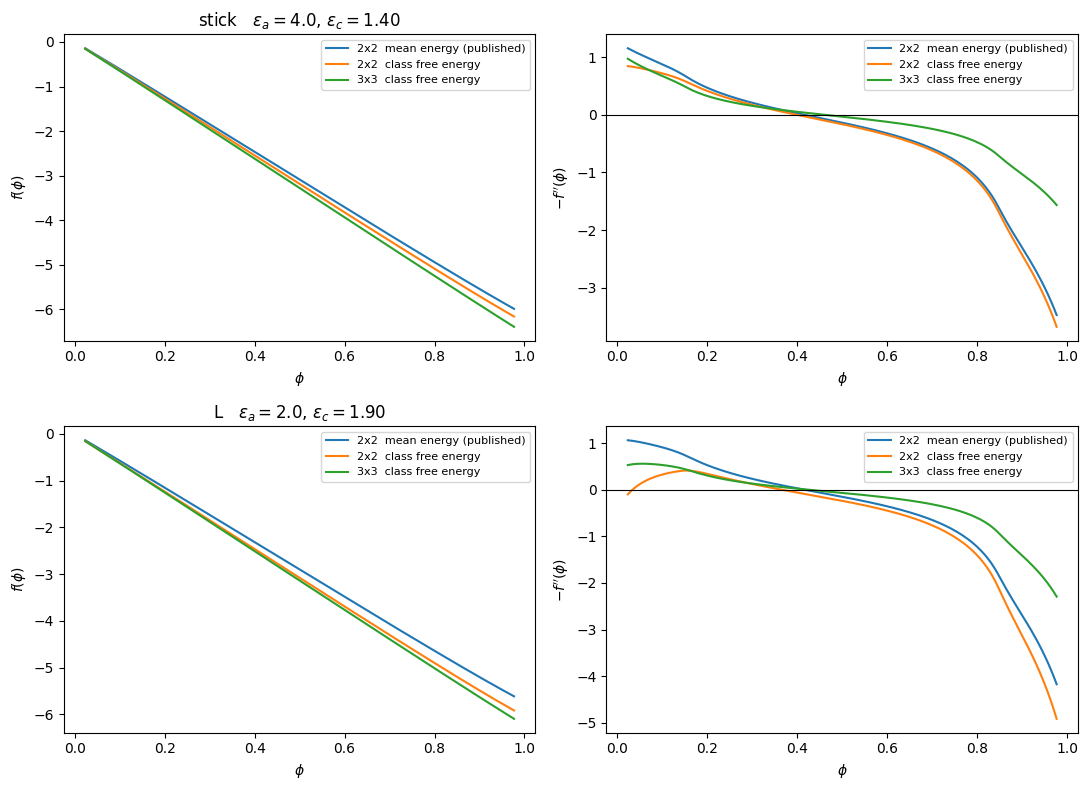

In [6]:
def show_point(name, eps_a, eps_c, variants, ax):
    for (n, ik, it, lab) in variants:
        t = time.time()
        c = free_energy_curve(name, eps_a, eps_c, n=n, phis=PHIS,
                              interior_key=ik, internal_term=it,
                              composition_key=COMPOSITION_KEY)
        a = analyse_curve(c); b = a['binodal']
        ax[0].plot(a['phi_inner'], a['f_smooth'], label=lab)
        ax[1].plot(a['phi_inner'], -a['fpp'], label=lab)
        print(f"  {lab:30s} P={c['info']['P']:>6,}  {time.time()-t:6.1f}s  "
              f"spinodal={[round(x,3) for x in a['spinodal_phis']]}  "
              f"binodal={(round(b['phi1'],3), round(b['phi2'],3)) if b else None}  "
              f"barrier={(b['barrier'] if b else 0.0):.2e}")
    ax[1].axhline(0.0, color='k', lw=0.8)
    ax[0].set_xlabel(r'$\phi$'); ax[0].set_ylabel(r'$f(\phi)$')
    ax[1].set_xlabel(r'$\phi$'); ax[1].set_ylabel(r"$-f''(\phi)$")
    ax[0].legend(fontsize=8); ax[1].legend(fontsize=8)

VARIANTS = [
    (2, 'none',      'mean_energy',       '2x2  mean energy (published)'),
    (2, 'none',      'class_free_energy', '2x2  class free energy'),
    (3, 'occupancy', 'class_free_energy', '3x3  class free energy'),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
# points chosen to sit inside the two-phase region for all three variants
print('stick, eps_a=4.0, eps_c=1.40')
show_point('stick', 4.0, 1.40, VARIANTS, axes[0])
print('L, eps_a=2.0, eps_c=1.90')
show_point('L', 2.0, 1.90, VARIANTS, axes[1])
axes[0][0].set_title(r'stick   $\epsilon_a=4.0$, $\epsilon_c=1.40$')
axes[1][0].set_title(r'L   $\epsilon_a=2.0$, $\epsilon_c=1.90$')
fig.tight_layout(); plt.show()

## 5. Critical line for the stick

The stick two-phase region is a half-plane in $\varepsilon_a$ (check the published npz: at
fixed $\varepsilon_c$, once $\varepsilon_a$ clears a threshold the system stays two-phase), so
a bisection on $\varepsilon_a$ is well posed.  `bisect_critical_eps_a` returns the smallest
$\varepsilon_a$ at which the convex-envelope construction finds a common tangent with barrier
$> 10^{-4}$ — the same criterion the published scan uses to mark a point two-phase.

**Do not use this routine for the L-shape** (see section 6).

In [7]:
RUN_STICK = False        # True to recompute (~25 min: the 3x3 rows dominate)
STICK_JSON = os.path.join(DATA, 'cluster_size_stick_critical_line.json')

EPS_C_STICK = [0.55, 0.65, 0.80, 1.00, 1.40, 1.80]
STICK_VARIANTS = [(2, 'none', 'mean_energy'), (2, 'none', 'class_free_energy'),
                  (3, 'occupancy', 'class_free_energy'), (3, 'occupancy', 'mean_energy')]

if RUN_STICK:
    results = []
    for ec in EPS_C_STICK:
        for (n, ik, it) in STICK_VARIANTS:
            t = time.time()
            ea = bisect_critical_eps_a('stick', ec, n=n, lo=0.0, hi=10.0, iters=10,
                                       phis=PHIS, interior_key=ik, internal_term=it,
                                       composition_key=COMPOSITION_KEY,
                                       barrier_tol=1e-4)
            results.append(dict(geometry='stick', eps_c=ec, n=n, interior_key=ik,
                                internal_term=it, eps_a_crit=float(ea),
                                wall=round(time.time() - t, 1)))
            print(results[-1], flush=True)
            json.dump(results, open(STICK_JSON, 'w'), indent=1)
else:
    results = json.load(open(STICK_JSON))

def pick(n, it):
    d = {r['eps_c']: r['eps_a_crit'] for r in results
         if r['n'] == n and r['internal_term'] == it}
    ecs = sorted(d)
    return np.array(ecs), np.array([d[e] for e in ecs])

print(f"\n{'eps_c':>7s} {'2x2 mean-E':>11s} {'2x2 class-F':>12s} {'3x3 class-F':>12s} "
      f"{'3x3 mean-E':>11s} {'2x2->3x3 (class-F)':>20s}")
x, a2m = pick(2, 'mean_energy')
_, a2c = pick(2, 'class_free_energy')
_, a3c = pick(3, 'class_free_energy')
_, a3m = pick(3, 'mean_energy')
for i, ec in enumerate(x):
    print(f"{ec:7.2f} {a2m[i]:11.3f} {a2c[i]:12.3f} {a3c[i]:12.3f} {a3m[i]:11.3f} "
          f"{a3c[i]-a2c[i]:+20.3f}")


  eps_c  2x2 mean-E  2x2 class-F  3x3 class-F  3x3 mean-E   2x2->3x3 (class-F)
   0.55       5.298        6.948        5.151       3.892               -1.797
   0.65       4.331        5.903        4.526       3.403               -1.377
   0.80       3.403        4.819        3.862       2.856               -0.957
   1.00       2.534        3.843        3.179       2.290               -0.664
   1.40       1.108        2.427        2.075       1.157               -0.352
   1.80       0.000        0.952        0.591       0.000               -0.361


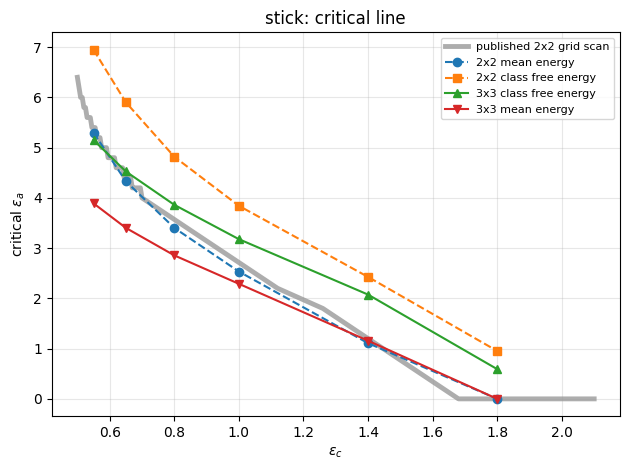

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))
npz = os.path.join(DATA, 'spinodal_simple_reduced_square_use4patch.npz')
if os.path.exists(npz):
    pts = np.load(npz)['points']
    ecs = np.unique(np.round(pts[:, 1], 6))
    line = [pts[np.abs(pts[:, 1] - c) < 1e-9, 0].min() for c in ecs]
    ax.plot(ecs, line, color='0.6', lw=3.5, alpha=0.8, label='published 2x2 grid scan')
for (n, it, style) in [(2, 'mean_energy', 'o--'), (2, 'class_free_energy', 's--'),
                       (3, 'class_free_energy', '^-'), (3, 'mean_energy', 'v-')]:
    xx, yy = pick(n, it)
    ax.plot(xx, yy, style, ms=6,
            label=f"{n}x{n} {'mean energy' if it == 'mean_energy' else 'class free energy'}")
ax.set_xlabel(r'$\epsilon_c$'); ax.set_ylabel(r'critical $\epsilon_a$')
ax.set_title('stick: critical line'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 6. Two-phase region maps (both geometries)

The L-shaped two-phase region is **not** a half-plane in $\varepsilon_a$: it is a band, so at
fixed $\varepsilon_c$ there is both a lower and an upper critical $\varepsilon_a$, and beyond
the upper edge strong directional bonding suppresses demixing again.  (The published L scan
shows this clearly; it is also why `spinodal_l_shaped.ipynb` adds the extra `len(sp) > 1`
condition that the stick notebook does not have.)  A bisection that assumes monotonicity would
silently return the wrong answer, so for the L the region is mapped on a grid instead.

`map_two_phase_region` records the barrier and the number of spinodal roots at every grid
point, so both acceptance criteria can be applied afterwards without recomputing.

In [9]:
RUN_REGION = False       # True to recompute (~30 min, dominated by the L 3x3 map)
REGION_JSON = os.path.join(DATA, 'cluster_size_region_maps.json')

REGION_JOBS = [
    ('stick', [0.5,0.7,0.9,1.1,1.4,1.7,2.0,2.3], [0.,1.,2.,3.,4.,5.,6.5,8.], 2, 'none',      'class_free_energy'),
    ('stick', [0.5,0.7,0.9,1.1,1.4,1.7,2.0,2.3], [0.,1.,2.,3.,4.,5.,6.5,8.], 2, 'none',      'mean_energy'),
    ('L',     [1.1,1.3,1.5,1.7,1.9,2.1,2.3],     [0.,1.,2.,3.,4.,6.,8.],     2, 'none',      'class_free_energy'),
    ('L',     [1.1,1.3,1.5,1.7,1.9,2.1,2.3],     [0.,1.,2.,3.,4.,6.,8.],     2, 'none',      'mean_energy'),
    ('stick', [0.5,0.7,0.9,1.1,1.4,1.7,2.0,2.3], [0.,1.,2.,3.,4.,5.,6.5,8.], 3, 'occupancy', 'class_free_energy'),
    ('L',     [1.1,1.3,1.5,1.7,1.9,2.1,2.3],     [0.,1.,2.,3.,4.,6.,8.],     3, 'occupancy', 'class_free_energy'),
]

if RUN_REGION:
    store = {}
    for (geom, ecs, eas, n, ik, it) in REGION_JOBS:
        key = f"{geom}_n{n}_{it}"
        print('===', key, flush=True)
        r = map_two_phase_region(geom, ecs, eas, n=n, phis=PHIS, interior_key=ik,
                                 internal_term=it, composition_key=COMPOSITION_KEY,
                                 verbose=False)
        store[key] = {k: (v.tolist() if isinstance(v, np.ndarray) else v)
                      for k, v in r.items()}
        store[key].update(geometry=geom, n=n, interior_key=ik, internal_term=it)
        json.dump(store, open(REGION_JSON, 'w'))
else:
    store = json.load(open(REGION_JSON))

def as_region(key):
    d = store[key]
    return {k: (np.array(v) if isinstance(v, list) else v) for k, v in d.items()}

for key in store:
    r = as_region(key)
    for req in (False, True):
        m = two_phase_mask(r, barrier_tol=1e-4, require_two_spinodal=req)
        print(f"{key:34s} require_two_spinodal={req!s:5s}  two-phase at "
              f"{m.sum():3d}/{m.size:3d} grid points")

stick_n2_class_free_energy         require_two_spinodal=False  two-phase at  36/ 64 grid points
stick_n2_class_free_energy         require_two_spinodal=True   two-phase at   5/ 64 grid points
stick_n2_mean_energy               require_two_spinodal=False  two-phase at  46/ 64 grid points
stick_n2_mean_energy               require_two_spinodal=True   two-phase at   4/ 64 grid points
L_n2_class_free_energy             require_two_spinodal=False  two-phase at  28/ 49 grid points
L_n2_class_free_energy             require_two_spinodal=True   two-phase at  10/ 49 grid points
L_n2_mean_energy                   require_two_spinodal=False  two-phase at  37/ 49 grid points
L_n2_mean_energy                   require_two_spinodal=True   two-phase at   9/ 49 grid points
stick_n3_class_free_energy         require_two_spinodal=False  two-phase at  42/ 64 grid points
stick_n3_class_free_energy         require_two_spinodal=True   two-phase at   4/ 64 grid points
L_n3_class_free_energy             requi

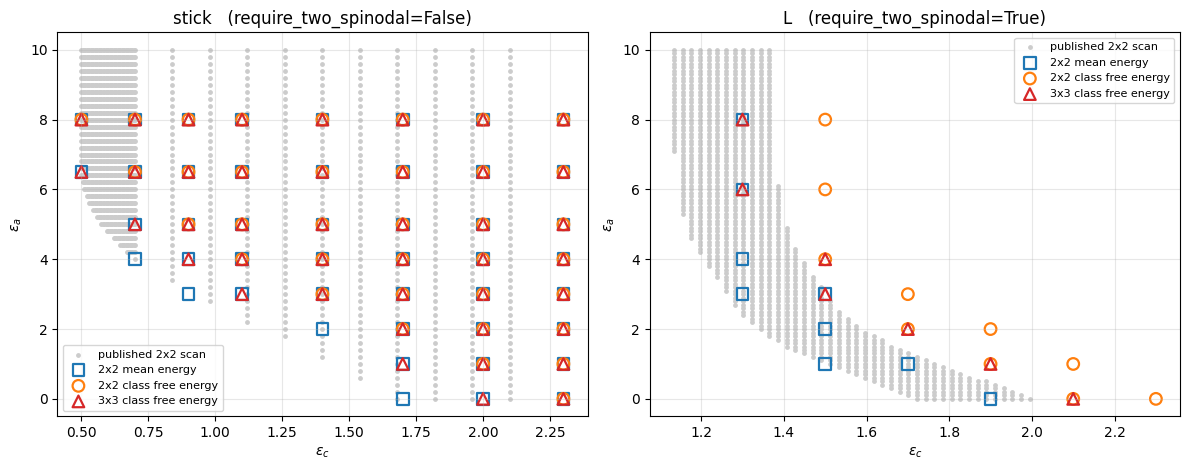

In [10]:
def plot_region(ax, key, color, label, require_two_spinodal=False, marker='s'):
    r = as_region(key)
    m = two_phase_mask(r, barrier_tol=1e-4, require_two_spinodal=require_two_spinodal)
    EC, EA = np.meshgrid(r['eps_cs'], r['eps_as'], indexing='ij')
    ax.scatter(EC[m], EA[m], s=70, marker=marker, facecolors='none',
               edgecolors=color, linewidths=1.6, label=label)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, geom, npz, req in zip(
        axes, ('stick', 'L'),
        ('spinodal_simple_reduced_square_use4patch',
         'spinodal_l_reduced_square_use4patch'),
        (False, True)):
    path = os.path.join(DATA, npz + '.npz')
    if os.path.exists(path):
        pts = np.load(path)['points']
        ax.scatter(pts[:, 1], pts[:, 0], s=6, c='0.8', label='published 2x2 scan')
    plot_region(ax, f'{geom}_n2_mean_energy',       'tab:blue',   '2x2 mean energy',       req, 's')
    plot_region(ax, f'{geom}_n2_class_free_energy', 'tab:orange', '2x2 class free energy', req, 'o')
    plot_region(ax, f'{geom}_n3_class_free_energy', 'tab:red',    '3x3 class free energy', req, '^')
    ax.set_xlabel(r'$\epsilon_c$'); ax.set_ylabel(r'$\epsilon_a$')
    ax.set_title(f"{geom}   (require_two_spinodal={req})")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig(os.path.join(DATA, '..', 'fig_cluster_size_2x2_vs_3x3.png'), dpi=160)
plt.show()

## 7. Notes for the response to R2C1

The structure of the argument, with numbers taken from sections 5 and 6:

1. **It is computable.**  The full $3\times3$ enumeration is $3^9 = 19{,}683$ (stick) and
   $5^9 = 1{,}953{,}125$ (L) microstates, collapsing to 1,665 / 12,720 boundary classes
   (3,330 / 25,440 once the composition is resolved).  The $2\times2$ class lists are
   unchanged by the composition key, so the published $2\times2$ numbers stand as printed.  The reduced nonlinear solve
   stays at $1 + 27$ unknowns, because the Newton dimension is set by the number of super-edge
   *types*, not by the number of classes.  A free-energy curve costs seconds.

2. **Report the shift at fixed class definition.**  Comparing `class_free_energy` at both
   cluster sizes is the controlled comparison; that number is the cluster-size sensitivity.

3. **Two structural facts a careful referee will ask about**, both absent at $2\times2$:
   * a $3\times3$ plaquette has an interior site the boundary signature cannot see, so the
     class label must carry the composition (`composition_key="components"`, equivalently
     the interior occupancy at this size) or the theory loses the dilute branch entirely —
     $\phi$ would be confined to $[2/27, 1]$ for the stick and $[4/45, 1]$ for the L;
   * the internal entropy inside a class has to be kept ($g_p = -\log Z_p$), or the
     coarse-graining error grows with cluster size and the comparison stops being controlled.

   Both are arguments *for* the minimal plaquette being a clean construction rather than
   an arbitrary truncation.

4. **The L-shaped two-phase region is a band in $\varepsilon_a$, not a half-plane** — worth
   stating explicitly, because it is a physical prediction (strong directional bonding
   eventually suppresses demixing in favour of the bonded network) and it is visible in the
   published figure.